# PMD reproducibility across donors (Fig S10A–C)

Part of the **[Fig. 2 chapter](fig2.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

_No explicit file reads detected (data may be read via variables or shell cells)._


In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [2]:
import numpy as np
import pandas as pd
from glob import glob
from scipy.sparse import csr_matrix
from scipy.stats import zscore
from concurrent.futures import ProcessPoolExecutor, as_completed

import pysam
import cooler
import anndata
import scanpy as sc
from sklearn.cluster import KMeans

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


In [3]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{indir}analysis/PMD_donor/'


In [4]:
import sys
import numpy as np
import pandas as pd
import pysam
import cooler
import anndata
import scanpy as sc
from concurrent.futures import ProcessPoolExecutor, as_completed
from sklearn.cluster import KMeans

def histcg(allc_path, chunk):
    with pysam.TabixFile(allc_path) as allc:
        hist = {}
        for i,(chrom,start,end) in enumerate(zip(chunk['chrom'].values, 
                                                 chunk['start'].values, 
                                                 chunk['end'].values)):
            tmp = f'{chrom}-{start}-{end}'
            data = []
            allc_lines = allc.fetch(chrom, start+1, end)
            for line in allc_lines:
                _, pos, _, _, mc, cov, *_ = line.split("\t")
                data.append([pos, mc, cov])

            data = pd.DataFrame(data, columns=['pos', 'mc', 'cov']).astype(int)
            posfilter = np.ones(data.shape[0]).astype(bool)
            for bed in rm_list:
                bedtmp = bed[chrom][np.logical_and(bed[chrom][:,0]<end, bed[chrom][:,1]>start)]
                for xx,yy in bedtmp:
                    posfilter[np.logical_and(data['pos']>=xx, data['pos']<=yy)] = False

            data = data.loc[posfilter]
            if data.shape[0]>0:
                hist[tmp] = np.histogram(data['mc']/data['cov'], bins=nbins, range=(0,1))[0]
            else:
                hist[tmp] = np.zeros(nbins)
        return hist
    
knn = 25
cpu = 32
nbins = 100

indir = f'{ENTEX_ROOT}/'
chrom_size_path = f'{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]
rm_list = []
for bed_path in [f'{REF_ROOT}/hg38/fasta/hg38.altseq.bed', 
                 f'{REF_ROOT}/blacklist/hg38-blacklist.v2.bed.gz']:
    bed = pd.read_csv(bed_path, sep='\t', header=None, index_col=None)
    bed = {chrom:bed.loc[bed[0]==chrom, [1,2]].values for chrom in chrom_sizes.index}
    rm_list.append(bed)
    
bed = cooler.util.binnify(chrom_sizes, 10000)
bed = bed.loc[bed['chrom'].isin(chrom_sizes.index)]
print(bed.shape[0])
bed['chunk'] = bed.index // 2000
allc_path = f'{ENTEX_ROOT}/merged_allc/tissue/NTb.CGN-Merge.allc.tsv.gz'
outdir = './'
ct = allc_path.split('/')[-1].split('.')[0]
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for i,chunk in bed.groupby('chunk'):
        future = executor.submit(
            histcg,
            allc_path=allc_path, 
            chunk=chunk,
        )
        futures[future] = i

    result = {}
    for future in as_completed(futures):
        tmp = futures[future]
        result.update(future.result())
        print(f'chunk{tmp} finished')

result = pd.DataFrame(result)
result = result.loc[:, (result.sum(axis=0)>0)]
result = result / result.sum(axis=0).values
adata = anndata.AnnData(X=result.T)
# sc.pp.neighbors(adata, n_neighbors=knn, use_rep='X')
# sc.tl.leiden(adata, resolution=0.1, random_state=0, flavor='igraph')
mcg = pd.Series(np.arange(100).dot(result), index=result.columns)



In [5]:
def kmeans(nc):
    tmp = KMeans(n_clusters=nc, random_state=0, n_init=10).fit(adata.X).labels_
    tmp = pd.Series(tmp, index=adata.obs_names, name='kmeans')
    clsuter_mcg = mcg.groupby(tmp).mean()
    rename_cluster = clsuter_mcg.sort_values().reset_index().reset_index().set_index('kmeans')['index']
    return tmp.map(rename_cluster)


In [6]:
for nc in range(3,7):
    cluster_key = f'kmeans{nc}'
    adata.obs[cluster_key] = kmeans(nc)
    print(nc)
    

In [7]:
def kmeans(nc):
    tmp = KMeans(n_clusters=nc, random_state=0, n_init=10).fit(adata.X).labels_
    tmp = pd.Series(tmp, index=adata.obs_names, name='kmeans')
    clsuter_mcg = mcg.groupby(tmp).mean()
    rename_cluster = clsuter_mcg.sort_values().reset_index().reset_index().set_index('kmeans')['index']
    return tmp.map(rename_cluster)

with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for nc in range(3,7):
        future = executor.submit(
            kmeans,
            nc=nc,
        )
        futures[future] = nc

    for future in as_completed(futures):
        nc = futures[future]
        cluster_key = f'kmeans{nc}'
        adata.obs[cluster_key] = future.result()

# for nc in range(3,7):
#     cluster_key = f'kmeans{nc}'
#     adata.obs[cluster_key] = KMeans(n_clusters=nc, random_state=0, n_init=10).fit(adata.X).labels_
#     clsuter_mcg = mcg.groupby(adata.obs[cluster_key]).mean()
#     rename_cluster = clsuter_mcg.sort_values().reset_index().reset_index().set_index(cluster_key)['index']
#     adata.obs[cluster_key] = adata.obs[cluster_key].map(rename_cluster)
# adata.write_h5ad(f'{outdir}{ct}_10kb_hist.h5ad')


In [8]:
chrom_size_path = f'{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


In [9]:
rm_list = []
for bed_path in [f'{REF_ROOT}/hg38/fasta/hg38.altseq.bed', 
                 f'{REF_ROOT}/blacklist/hg38-blacklist.v2.bed.gz']:
    bed = pd.read_csv(bed_path, sep='\t', header=None, index_col=None)
    bed = {chrom:bed.loc[bed[0]==chrom, [1,2]].values for chrom in chrom_sizes.index}
    rm_list.append(bed)
    

In [10]:
nbins = 100


In [11]:
bed = cooler.util.binnify(chrom_sizes, 10000)
bed = bed.loc[bed['chrom'].isin(chrom_sizes.index)]
print(bed.shape[0])
bed['chunk'] = bed.index // 2000


In [12]:
def histcg(allc_path, chunk):
    with pysam.TabixFile(allc_path) as allc:
        hist = {}
        for i,(chrom,start,end) in enumerate(zip(chunk['chrom'].values, 
                                                 chunk['start'].values, 
                                                 chunk['end'].values)):
            npos = (end - start)# // posres * posres
            if npos==0:
                continue
            region = f'{chrom}-{start}-{end}'
            data = []
            allc_lines = allc.fetch(chrom, start+1, end)
            for line in allc_lines:
                _, pos, _, context, mc, cov, *_ = line.split("\t")
                if context[1] in 'G':
                    data.append([pos, mc, cov])

            data = pd.DataFrame(data, columns=['pos', 'mc', 'cov']).astype(int)
            posfilter = np.ones(data.shape[0]).astype(bool)
            for bed in rm_list:
                bedtmp = bed[chrom][np.logical_and(bed[chrom][:,0]<end, bed[chrom][:,1]>start)]
                for xx,yy in bedtmp:
                    posfilter[np.logical_and(data['pos']>=xx, data['pos']<=yy)] = False

            data = data.loc[posfilter]
            
            tmp = data['mc'] / data['cov']
            
            if data.shape[0]>0:
                hist[region] = np.histogram(tmp, bins=nbins, range=(0,1))[0]
            else:
                hist[region] = np.zeros(nbins)
        return hist
    

In [13]:
allc_path_list = np.sort(glob(f'{outdir}allc/*.allc.tsv.gz'))
allc_path_list = {allc_path.split('/')[-1].split('.')[0]:allc_path for allc_path in allc_path_list}
print(len(allc_path_list))


In [14]:
knn = 25
cpu = 32
nbins = 100

for ct in allc_path_list:
    allc_path = allc_path_list[ct]
    with ProcessPoolExecutor(cpu) as executor:
        futures = {}
        for i,chunk in bed.groupby('chunk'):
            future = executor.submit(
                histcg,
                allc_path=allc_path, 
                chunk=chunk,
            )
            futures[future] = i

        result = {}
        for future in as_completed(futures):
            tmp = futures[future]
            result.update(future.result())
            print(f'chunk{tmp} finished')
            
    result = pd.DataFrame(result)
    result = result.loc[:, (result.sum(axis=0)>0)]
    result = result / result.sum(axis=0).values
    adata = anndata.AnnData(X=result.T)
    mcg = pd.Series(np.arange(100).dot(result), index=result.columns)
    for nc in range(3,7):
        cluster_key = f'kmeans{nc}'
        adata.obs[cluster_key] = KMeans(n_clusters=nc, random_state=0, n_init=10).fit(adata.X).labels_
        mcg = mcg.groupby(adata.obs[cluster_key]).mean()
        rename_cluster = mcg.sort_values().reset_index().reset_index().set_index(cluster_key)['index']
        adata.obs[cluster_key] = adata.obs[cluster_key].map(rename_cluster)
    # sc.pp.neighbors(adata, n_neighbors=knn, use_rep='X')
    # sc.tl.leiden(adata, resolution=0.1, random_state=0, flavor='igraph')
    adata.write_h5ad(f'{outdir}{ct}_10kb_hist.h5ad')


In [15]:
ct = 'Epi-TPB'
# ct = 'T-Mem'
adata_list = []
donor_list = []
for adata_path in np.sort(glob(f'{outdir}{ct}*_10kb_hist.h5ad')):
    donor = adata_path.split('/')[-1].split('_')[1]
    adata_list.append(anndata.read_h5ad(adata_path))
    donor_list.append(donor)

selc = adata_list[0].obs.index.intersection(adata_list[1].obs.index)


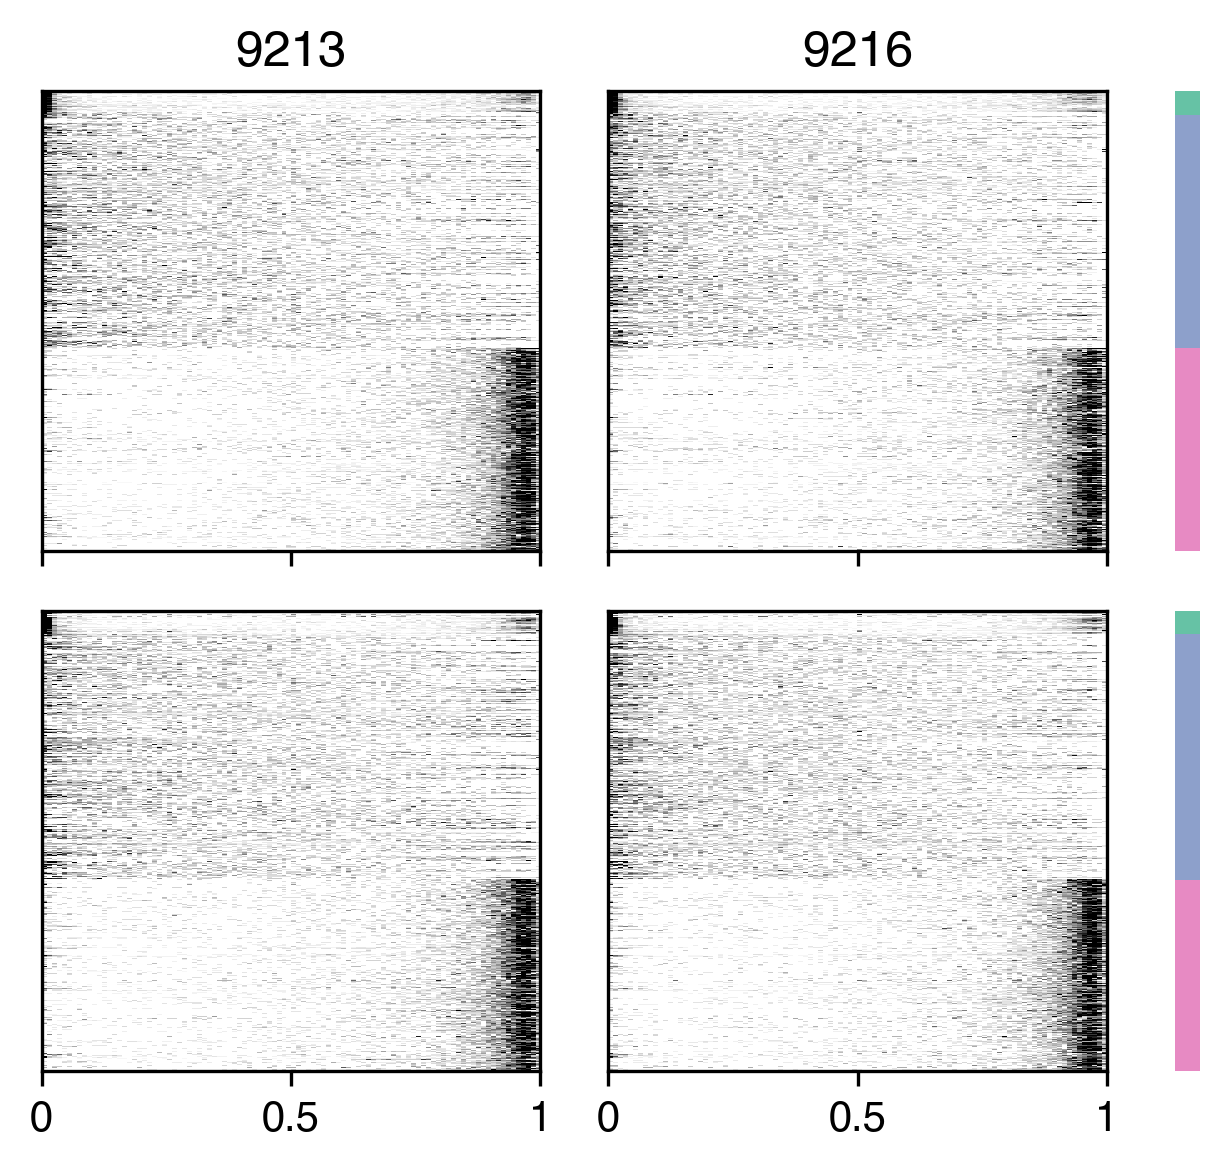

In [16]:
import matplotlib.patches as patches

nc = 3
cluster_key = f'kmeans{nc}'
cluster_color = np.array(sns.color_palette('Set2', 4))[[0,2,3]]
# leg_order = meta.groupby('L1')['mCGFrac'].median().sort_values().index

fig, axes = plt.subplots(2, 3, figsize=(4.2, 4), sharey='all', sharex='col', dpi=300, 
                         gridspec_kw={'width_ratios': [20,20,1]})

for i in range(2):
    # label = adata.obs[cluster_key]
    adata = adata_list[i]
    idx = adata.obs.loc[selc, cluster_key].sort_values().index
    offset = list(adata.obs.loc[idx, cluster_key].value_counts().sort_index().cumsum())
    offset = [0] + offset
    
    for j in range(2):
        ax = axes[i, j]
        # sns.despine(ax=ax, left=True, bottom=True)
        adata = adata_list[j]
        tmp = adata[idx].X
        ax.imshow(tmp, cmap='vlag', vmax=np.percentile(tmp, 99), aspect='auto', 
                  interpolation='none', rasterized=True)
        if i==0:
            ax.set_title(donor_list[j])
        ax.set_xticks([-0.5, 49.5, 99.5])
        ax.set_xticklabels([0, 0.5, 1])
        ax.set_yticks([])
    
    ax = axes[i, -1]
    ax.axis('off')
    for k in range(nc):
        rect = patches.Rectangle((0, offset[k]), 1, offset[k+1]-offset[k], linewidth=0, edgecolor='none', facecolor=cluster_color[k])
        ax.add_patch(rect)
        # ax.text(np.mean(offset[i:(i+2)]), -0.2, donor_list[i], rotation=90, fontsize=10, horizontalalignment='left', verticalalignment='top')
    
fig.tight_layout()
fig.savefig(f'PMD_donor/{ct}.10kb_hist_donor.pdf', transparent=True)


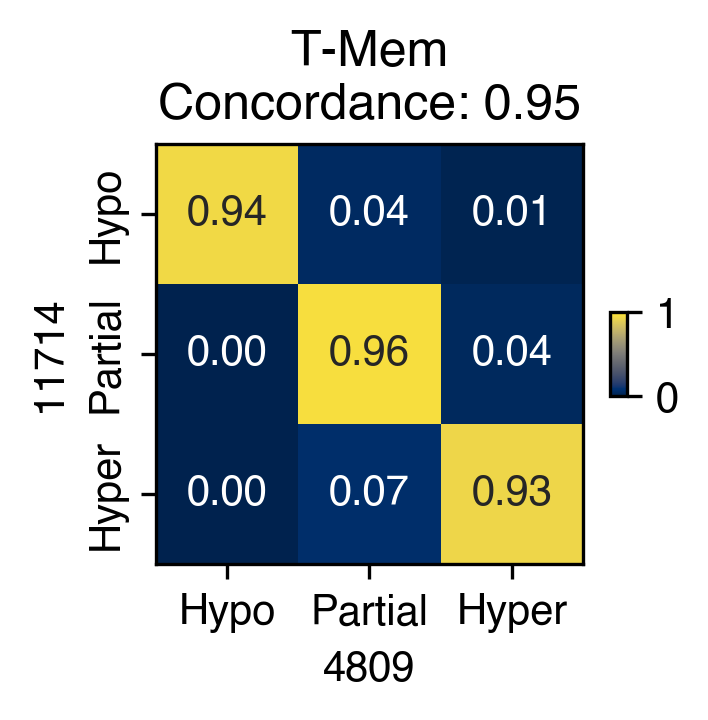

In [17]:
rename_label = {0:'Hypo', 1:'Partial', 2:'Hyper'}
confusion_matrix = pd.DataFrame([adata_list[0].obs.loc[selc, cluster_key], adata_list[1].obs.loc[selc, cluster_key]], index=donor_list).T.value_counts().unstack().fillna(0)
confusion_matrix = confusion_matrix.rename(columns=rename_label, index=rename_label)
acc = np.diag(confusion_matrix).sum() / confusion_matrix.values.sum()
fig, ax = plt.subplots(figsize=(2.5,2.5), dpi=300)
sns.heatmap(confusion_matrix / confusion_matrix.sum(axis=1).values[:, None],
            annot=True, fmt='.2f', cmap='cividis', ax=ax, vmin=0, vmax=1,
            cbar_kws={"shrink": 0.2, "aspect": 5, "ticks": [0, 1]})
sns.despine(ax=ax, top=False, right=False, left=False, bottom=False)
# ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title(f'{ct}\nConcordance: {acc:.2f}')
cbar = ax.collections[0].colorbar
cbar.ax.spines['outline'].set_linewidth(0.8)
fig.tight_layout()
fig.savefig(f'PMD_donor/{ct}.10kb_hist_confusion.pdf', transparent=True)
